# **Hierarchical Clustering**

Find hidden groups in data

Understand relationships between data points

Organize similar data together

Build clusters step by step



# **Simple Idea**

Suppose you have mall customers.

You do NOT know:

who are premium customers
who spend less
who are average buyers

Hierarchical clustering automatically groups them based on similarity.

In [1]:
pip install kaggle

In [4]:
!unzip /content/asdf.zip

Archive:  /content/asdf.zip
  inflating: Mall_Customers.csv      


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [6]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [7]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

In [11]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [12]:
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

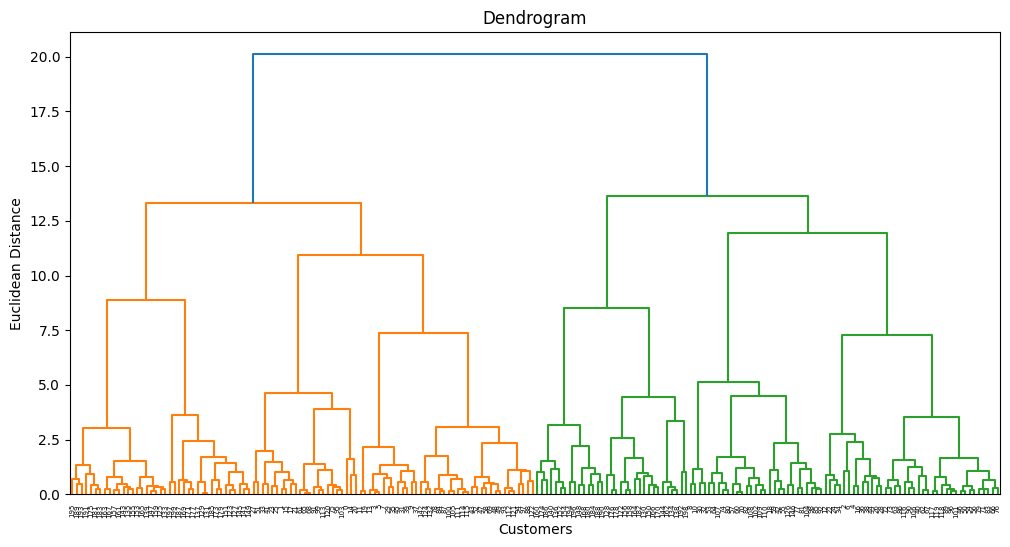

In [14]:
linked = linkage(X_scaled, method='ward') # method used to merge clusters # creates hierarchical clusters.

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [15]:
model = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

clusters = model.fit_predict(X_scaled)

In [16]:
df['Cluster'] = clusters

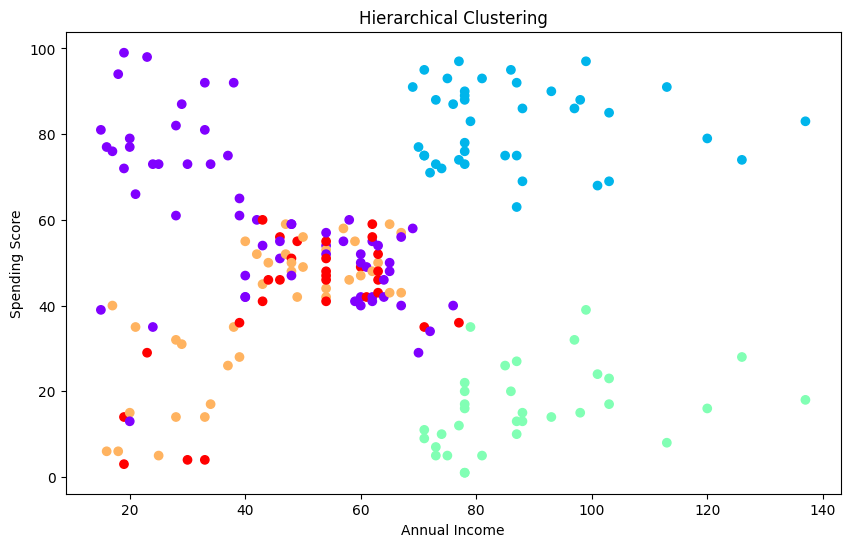

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='rainbow'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("Hierarchical Clustering")

plt.show()